<a href="https://colab.research.google.com/github/smodole/smodole/blob/main/multilingual.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Please upload the 'phonetic_data.csv' file:


Saving phonetic_data.csv to phonetic_data.csv
User uploaded file "phonetic_data.csv"


Streaming output truncated to the last 5000 lines.



===== PT =====
Epoch 1/15 Loss: 88.7363
Epoch 2/15 Loss: 53.3467
Epoch 3/15 Loss: 37.6938
Epoch 4/15 Loss: 28.4642
Epoch 5/15 Loss: 23.5736
Epoch 6/15 Loss: 19.5046
Epoch 7/15 Loss: 16.5044
Epoch 8/15 Loss: 15.1931
Epoch 9/15 Loss: 14.5482
Epoch 10/15 Loss: 12.4456
Epoch 11/15 Loss: 11.1240
Epoch 12/15 Loss: 10.5639
Epoch 13/15 Loss: 10.5974
Epoch 14/15 Loss: 9.3540
Epoch 15/15 Loss: 9.8676

PT CNN
              precision    recall  f1-score   support

           0       0.90      0.95      0.92      3685
           1       0.93      0.85      0.89      2694

    accuracy                           0.91      6379
   macro avg       0.91      0.90      0.91      6379
weighted avg       0.91      0.91      0.91      6379



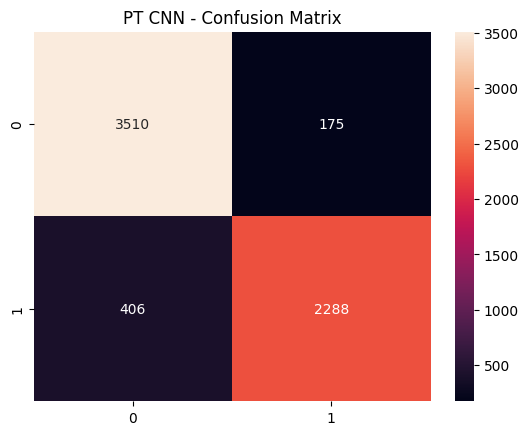

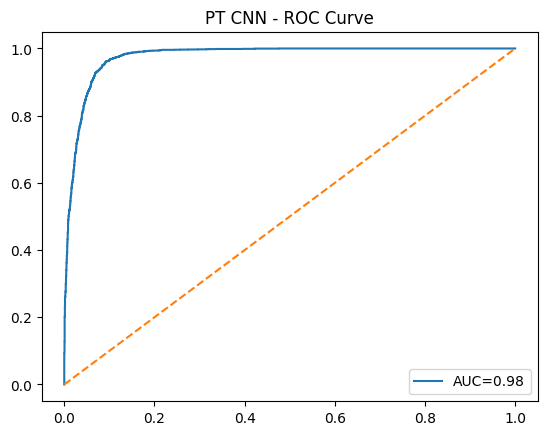


PT CNN+SVM
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      3685
           1       0.85      0.78      0.81      2694

    accuracy                           0.85      6379
   macro avg       0.85      0.84      0.84      6379
weighted avg       0.85      0.85      0.85      6379



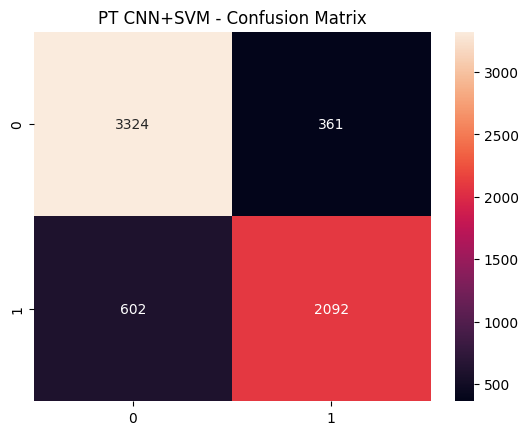

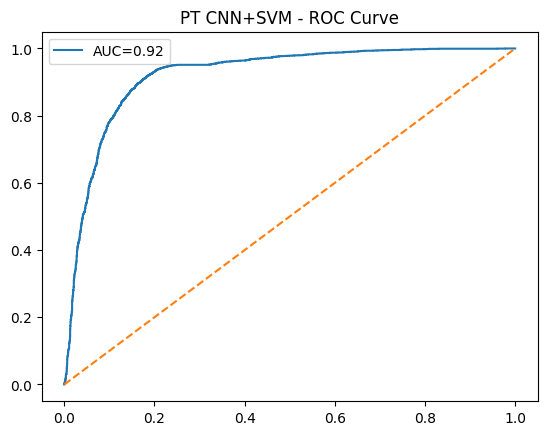


===== EN =====
Epoch 1/15 Loss: 9.8081
Epoch 2/15 Loss: 2.5924
Epoch 3/15 Loss: 1.5479
Epoch 4/15 Loss: 1.3035
Epoch 5/15 Loss: 1.1202
Epoch 6/15 Loss: 1.0721
Epoch 7/15 Loss: 1.0848
Epoch 8/15 Loss: 0.9868
Epoch 9/15 Loss: 1.0784
Epoch 10/15 Loss: 1.0025
Epoch 11/15 Loss: 0.9071
Epoch 12/15 Loss: 1.0631
Epoch 13/15 Loss: 0.9342
Epoch 14/15 Loss: 0.8941
Epoch 15/15 Loss: 0.9205

EN CNN
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       302
           1       0.99      0.98      0.98       298

    accuracy                           0.98       600
   macro avg       0.98      0.98      0.98       600
weighted avg       0.98      0.98      0.98       600



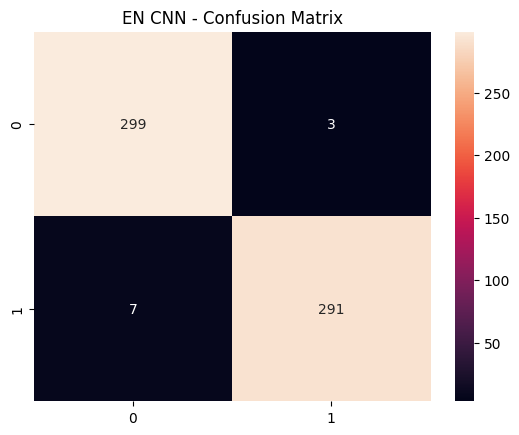

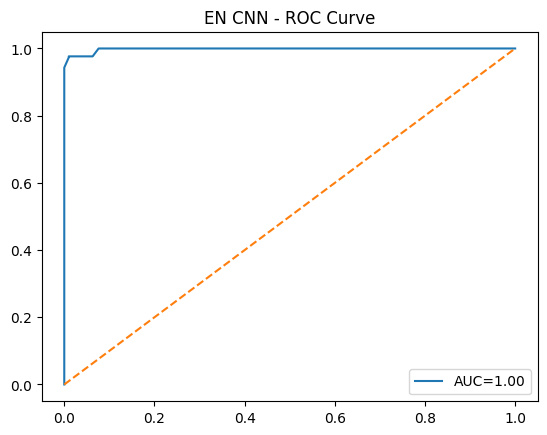


EN CNN+SVM
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       302
           1       1.00      0.94      0.97       298

    accuracy                           0.97       600
   macro avg       0.97      0.97      0.97       600
weighted avg       0.97      0.97      0.97       600



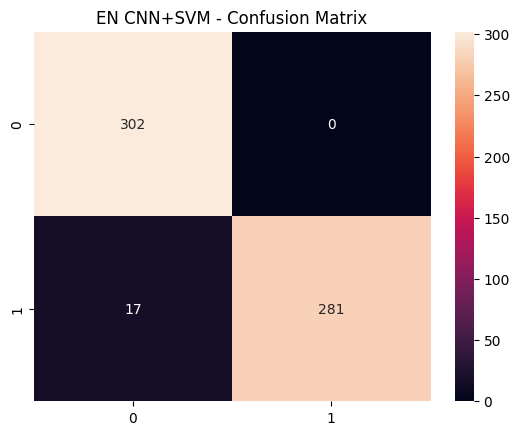

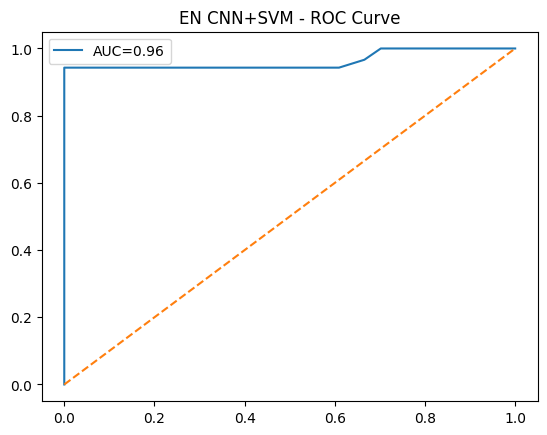


===== ZH =====
Epoch 1/15 Loss: 1.1525
Epoch 2/15 Loss: 1.3546
Epoch 3/15 Loss: 1.0895
Epoch 4/15 Loss: 1.2105
Epoch 5/15 Loss: 1.2050
Epoch 6/15 Loss: 1.1696
Epoch 7/15 Loss: 1.0797
Epoch 8/15 Loss: 1.0787
Epoch 9/15 Loss: 0.9440
Epoch 10/15 Loss: 0.8339
Epoch 11/15 Loss: 1.0530
Epoch 12/15 Loss: 0.9456
Epoch 13/15 Loss: 0.9370
Epoch 14/15 Loss: 0.8759
Epoch 15/15 Loss: 0.7871

ZH CNN
              precision    recall  f1-score   support

           0       0.25      0.12      0.17         8
           1       0.79      0.90      0.84        30

    accuracy                           0.74        38
   macro avg       0.52      0.51      0.51        38
weighted avg       0.68      0.74      0.70        38



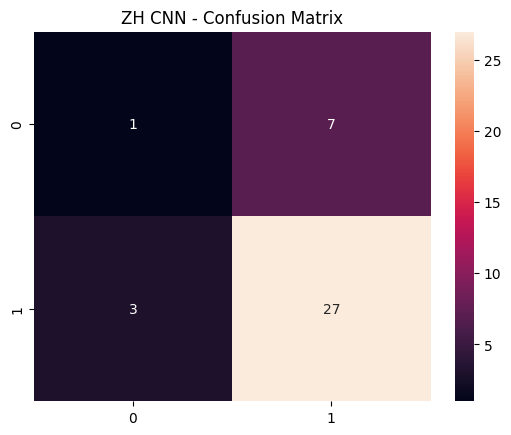

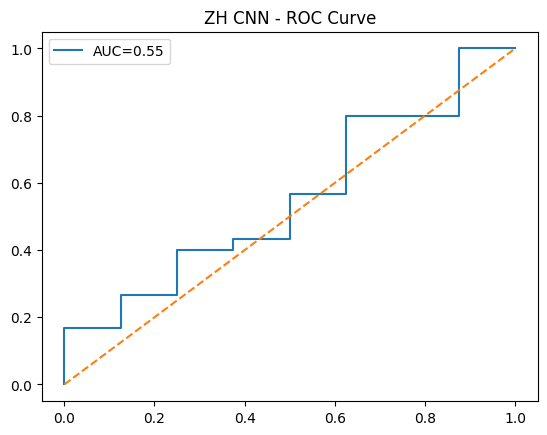


ZH CNN+SVM
              precision    recall  f1-score   support

           0       0.29      0.25      0.27         8
           1       0.81      0.83      0.82        30

    accuracy                           0.71        38
   macro avg       0.55      0.54      0.54        38
weighted avg       0.70      0.71      0.70        38



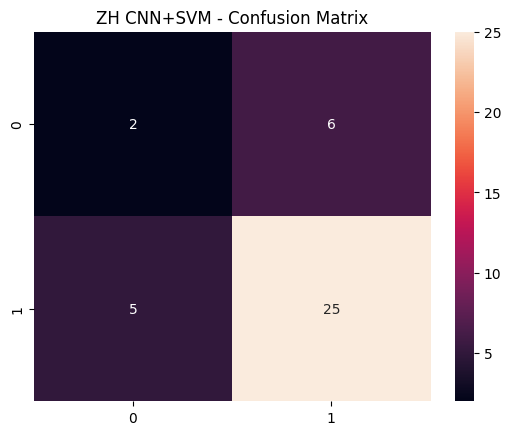

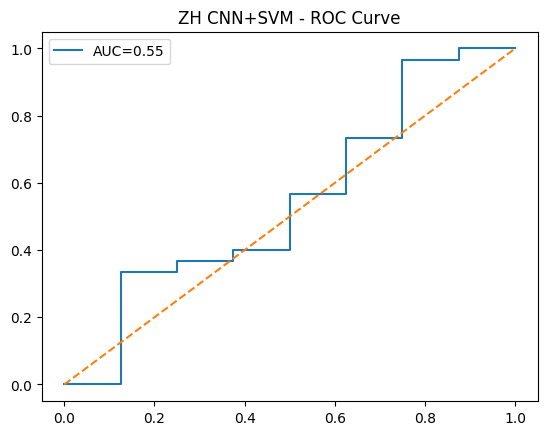


===== COMBINED =====
Epoch 1/15 Loss: 93.4723
Epoch 2/15 Loss: 55.6563
Epoch 3/15 Loss: 41.1616
Epoch 4/15 Loss: 33.3949
Epoch 5/15 Loss: 26.3128
Epoch 6/15 Loss: 23.4424
Epoch 7/15 Loss: 20.8507
Epoch 8/15 Loss: 18.8460
Epoch 9/15 Loss: 17.0136
Epoch 10/15 Loss: 15.3693
Epoch 11/15 Loss: 14.0902
Epoch 12/15 Loss: 12.9475
Epoch 13/15 Loss: 12.6989
Epoch 14/15 Loss: 13.1496
Epoch 15/15 Loss: 12.0918

COMBINED CNN
              precision    recall  f1-score   support

           0       0.93      0.96      0.94      3956
           1       0.94      0.90      0.92      3061

    accuracy                           0.93      7017
   macro avg       0.93      0.93      0.93      7017
weighted avg       0.93      0.93      0.93      7017



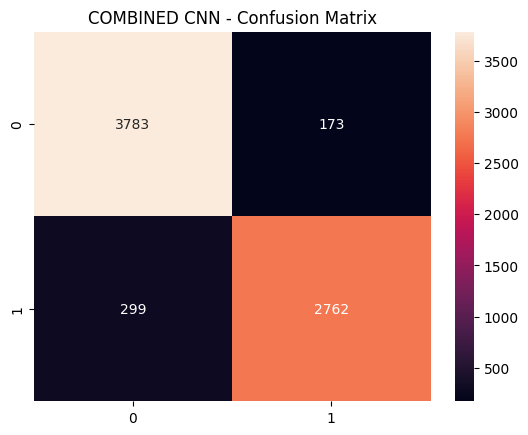

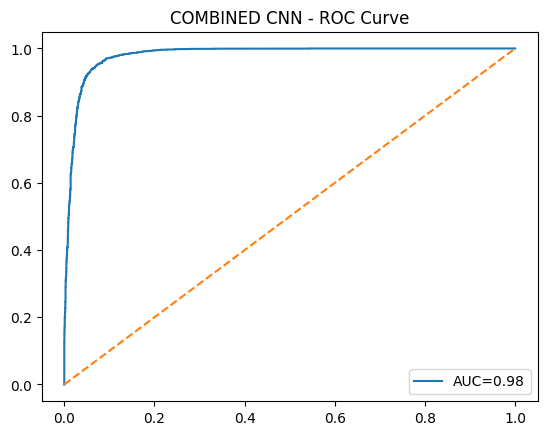


COMBINED CNN+SVM
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      3956
           1       0.86      0.80      0.83      3061

    accuracy                           0.86      7017
   macro avg       0.86      0.85      0.86      7017
weighted avg       0.86      0.86      0.86      7017



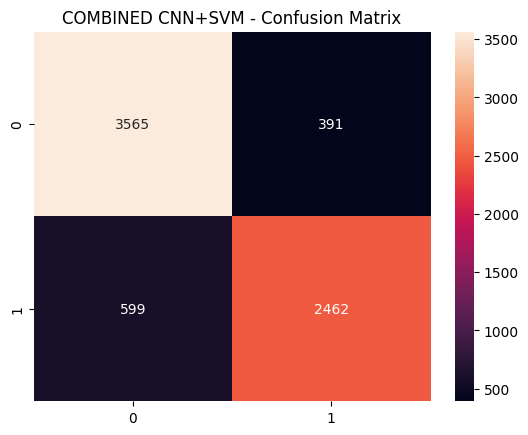

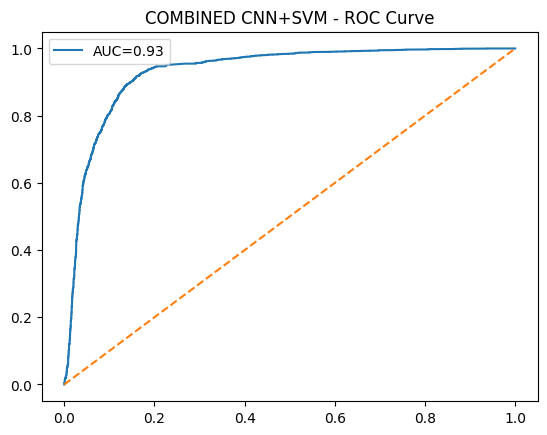


Statistical Test (F1 comparison)
t-stat: 2.6764776199270157 p-value: 0.07527409989752983


In [3]:
# ============================================================
# HYBRID CNN–SVM PHONETIC SIMILARITY SYSTEM
# ============================================================
!pip install torch torchvision torchaudio scikit-learn pandas numpy matplotlib seaborn epitran regex unidecode ftfy
# Optional for better English G2P fallback
!pip install phonemizer

from IPython.display import clear_output
clear_output(wait=True)

# =========================
# IMPORTS
# =========================
import os
import re
import regex as re2
import random
import numpy as np
import pandas as pd
import unicodedata
from unidecode import unidecode
from ftfy import fix_text

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn import svm
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc
)
from scipy.stats import ttest_rel

import matplotlib.pyplot as plt
import seaborn as sns

# IPA
import epitran
# Optional fallback for English (if needed)
try:
    from phonemizer import phonemize
    HAS_PHONEMIZER = True
except:
    HAS_PHONEMIZER = False

# =========================
# GLOBAL CONFIG / HYPERPARAMETERS
# =========================
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# N-gram settings for phonetic features
NGRAM = 3
MAX_LEN = 30         # max number of n-grams (sequence length)
EMBED_DIM = 128      # CNN embedding dimension
PHON_FEAT_DIM = 32   # dimension for each n-gram vector
BATCH_SIZE = 128
EPOCHS = 15
LR = 1e-3
DROPOUT = 0.3

# SVM params (tuned defaults)
SVM_C = 2.0
SVM_GAMMA = 'scale'

# CV
N_SPLITS = 5

# =========================
# 2. TEXT NORMALIZATION + MOJIBAKE REPAIR (ZH-aware)
# =========================
def normalize_text(text):
    """
    - Fix encoding issues (mojibake)
    - Normalize unicode (NFKC)
    - Lowercase
    - Clean whitespace and punctuation
    """
    if pd.isna(text):
        return ""

    text = fix_text(str(text))
    text = unicodedata.normalize("NFKC", text)
    text = text.strip().lower()

    # remove excessive punctuation but keep letters/numbers
    text = re2.sub(r"[^\p{L}\p{N}\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

# =========================
# 3. IPA TRANSCRIPTION (Epitran)
# =========================
EPITRAN_MAP = {
    "EN": "eng-Latn",
    "PT": "por-Latn",
    "ZH": "cmn-Hans"
}

EPIS = {k: epitran.Epitran(v) for k, v in EPITRAN_MAP.items()}

def to_ipa(text, lang):
    """
    Converts text to IPA using Epitran.
    Includes fallback for English using phonemizer if needed.
    """
    try:
        ipa = EPIS[lang].transliterate(text)
        if ipa and ipa.strip():
            return ipa
    except:
        pass

    # fallback (EN only)
    if lang == "EN" and HAS_PHONEMIZER:
        try:
            return phonemize(text, language='en-us', backend='espeak')
        except:
            return text

    return text

# =========================
# 4. N-GRAM FEATURE EXTRACTION
# =========================
def get_ngrams(seq, n=NGRAM):
    seq = list(seq)
    return ["".join(seq[i:i+n]) for i in range(len(seq)-n+1)] if len(seq) >= n else ["".join(seq)]

# random embedding dictionary (learnable-like but fixed for simplicity)
NGRAM_EMBED = {}

def ngram_to_vec(ng):
    if ng not in NGRAM_EMBED:
        NGRAM_EMBED[ng] = np.random.normal(0, 1, PHON_FEAT_DIM)
    return NGRAM_EMBED[ng]

def encode_ipa(ipa):
    ngrams = get_ngrams(ipa)
    vecs = [ngram_to_vec(ng) for ng in ngrams]

    # pad/truncate to MAX_LEN
    if len(vecs) < MAX_LEN:
        vecs += [np.zeros(PHON_FEAT_DIM)] * (MAX_LEN - len(vecs))
    else:
        vecs = vecs[:MAX_LEN]

    return np.array(vecs)  # shape (MAX_LEN, PHON_FEAT_DIM)

# =========================
# 5. DATA AUGMENTATION
# =========================
def augment_pair(ipa1, ipa2, label):
    """
    Linguistically motivated augmentations:
    - phoneme substitution (nearby symbols)
    - insertion/deletion
    """
    def mutate(ipa):
        ipa = list(ipa)
        if not ipa:
            return ipa

        i = random.randint(0, len(ipa)-1)
        ipa[i] = random.choice(ipa)  # substitution

        if random.random() < 0.3 and len(ipa) > 2:
            ipa.pop(i)  # deletion

        if random.random() < 0.3:
            ipa.insert(i, random.choice(ipa))  # insertion

        return "".join(ipa)

    return mutate(ipa1), mutate(ipa2), label

def augment_dataset(df, min_size=3000):
    """
    If dataset is small, augment until threshold is reached.
    """
    rows = df.copy()
    augmented = []

    while len(rows) + len(augmented) < min_size:
        sample = rows.sample(1).iloc[0]
        ipa1, ipa2, y = sample["ipa1"], sample["ipa2"], sample["label"]

        a1, a2, y = augment_pair(ipa1, ipa2, y)
        augmented.append([a1, a2, y, sample["language"]])

    if augmented:
        aug_df = pd.DataFrame(augmented, columns=["ipa1", "ipa2", "label", "language"])
        return pd.concat([rows, aug_df], ignore_index=True)

    return rows

# =========================
# 6. CNN MODEL
# =========================
class CNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(PHON_FEAT_DIM, 64, 3, padding=1)
        self.conv2 = nn.Conv1d(64, 128, 3, padding=1)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.dropout = nn.Dropout(DROPOUT)
        self.fc = nn.Linear(128, EMBED_DIM)
        self.classifier = nn.Linear(EMBED_DIM * 2, 2)

    def embed(self, x):
        x = x.permute(0, 2, 1)
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = self.pool(x).squeeze(-1)
        x = self.dropout(x)
        return self.fc(x)

    def forward(self, x1, x2):
        z1 = self.embed(x1)
        z2 = self.embed(x2)
        z = torch.cat([z1, z2], dim=1)
        return self.classifier(z), z1, z2

# =========================
# 7. TRAINING LOOP (CNN)
# =========================
def train_cnn(model, train_loader):
    model.to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0

        for x1, x2, y in train_loader:
            x1, x2, y = x1.to(DEVICE), x2.to(DEVICE), y.to(DEVICE)

            logits, _, _ = model(x1, x2)
            loss = criterion(logits, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{EPOCHS} Loss: {total_loss:.4f}")

    return model

# =========================
# 8. FEATURE EXTRACTION (for SVM)
# =========================
def extract_features(model, loader):
    model.eval()
    feats, labels = [], []

    with torch.no_grad():
        for x1, x2, y in loader:
            x1, x2 = x1.to(DEVICE), x2.to(DEVICE)
            z1 = model.embed(x1).cpu().numpy()
            z2 = model.embed(x2).cpu().numpy()

            for i in range(len(z1)):
                delta = np.abs(z1[i] - z2[i])
                cos = np.dot(z1[i], z2[i]) / (np.linalg.norm(z1[i]) * np.linalg.norm(z2[i]) + 1e-8)
                feats.append(np.concatenate([delta, [cos]]))
                labels.append(y[i].item())

    return np.array(feats), np.array(labels)

# =========================
# 9. DATA LOADER
# =========================
class PairDataset(torch.utils.data.Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x1 = encode_ipa(row["ipa1"])
        x2 = encode_ipa(row["ipa2"])
        y = int(row["label"])
        return torch.tensor(x1, dtype=torch.float32), \
               torch.tensor(x2, dtype=torch.float32), \
               torch.tensor(y, dtype=torch.long)

# =========================
# 10. EVALUATION + PLOTS
# =========================
def evaluate(y_true, y_pred, y_prob, title):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\n{title}")
    print(classification_report(y_true, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"{title} - Confusion Matrix")
    plt.show()

    # ROC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC={roc_auc:.2f}")
    plt.plot([0,1],[0,1],'--')
    plt.legend()
    plt.title(f"{title} - ROC Curve")
    plt.show()

    return acc, prec, rec, f1

# =========================
# 11. MAIN PIPELINE
# =========================
def run_experiment(df, name):

    print(f"\n===== {name} =====")

    # Split 75/20/5
    train, temp = train_test_split(df, test_size=0.25, stratify=df["label"])
    test, eval_ = train_test_split(temp, test_size=0.2)

    train_ds = PairDataset(train)
    test_ds = PairDataset(test)

    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = torch.utils.data.DataLoader(test_ds, batch_size=BATCH_SIZE)

    # CNN
    model = CNNModel()
    model = train_cnn(model, train_loader)

    # CNN evaluation
    y_true, y_pred, y_prob = [], [], []

    model.eval()
    with torch.no_grad():
        for x1, x2, y in test_loader:
            logits, _, _ = model(x1.to(DEVICE), x2.to(DEVICE))
            probs = torch.softmax(logits, dim=1)[:,1].cpu().numpy()
            preds = torch.argmax(logits, dim=1).cpu().numpy()

            y_true.extend(y.numpy())
            y_pred.extend(preds)
            y_prob.extend(probs)

    cnn_metrics = evaluate(y_true, y_pred, y_prob, f"{name} CNN")

    # Hybrid (CNN + SVM)
    X_train, y_train = extract_features(model, train_loader)
    X_test, y_test = extract_features(model, test_loader)

    clf = svm.SVC(kernel='rbf', probability=True, C=SVM_C, gamma=SVM_GAMMA)
    clf.fit(X_train, y_train)

    preds = clf.predict(X_test)
    probs = clf.predict_proba(X_test)[:,1]

    svm_metrics = evaluate(y_test, preds, probs, f"{name} CNN+SVM")

    return cnn_metrics, svm_metrics

# =========================
# 12. LOAD DATA + PREPROCESS
# =========================
def load_and_prepare(csv_path):
    df = pd.read_csv(csv_path)

    # normalize
    df["trademark1"] = df["trademark1"].apply(normalize_text)
    df["trademark2"] = df["trademark2"].apply(normalize_text)

    # IPA
    df["ipa1"] = df.apply(lambda x: to_ipa(x["trademark1"], x["language"]), axis=1)
    df["ipa2"] = df.apply(lambda x: to_ipa(x["trademark2"], x["language"]), axis=1)

    # augmentation
    df = augment_dataset(df)

    return df

# =========================
# 13. RUN EVERYTHING
# =========================
if __name__ == "__main__":


    from google.colab import files

    print("Please upload the 'phonetic_data.csv' file:")
    uploaded = files.upload()

    for fn in uploaded.keys():
      print(f'User uploaded file "{fn}"')


    # Load uploaded dataset
    #df = pd.read_csv("phonetic_data.csv")


    df = load_and_prepare("phonetic_data.csv")

    results = []

    # per language
    for lang in df["language"].unique():
        sub = df[df["language"] == lang]
        cnn_m, svm_m = run_experiment(sub, lang)
        results.append((lang, cnn_m, svm_m))

    # combined
    cnn_m, svm_m = run_experiment(df, "COMBINED")
    results.append(("COMBINED", cnn_m, svm_m))

    # =========================
    # STATISTICAL TEST
    # =========================
    cnn_scores = [r[1][3] for r in results]  # F1
    svm_scores = [r[2][3] for r in results]

    t_stat, p_val = ttest_rel(cnn_scores, svm_scores)
    print("\nStatistical Test (F1 comparison)")
    print("t-stat:", t_stat, "p-value:", p_val)

In [ ]:
# ============================================================
# COMPLETE SCRIPT: DOUBLE METAPHONE TRADEMARK SIMILARITY
# ============================================================

import pandas as pd
import re
from itertools import combinations
# Install metaphone library
!pip install metaphone
from metaphone import doublemetaphone
from tqdm import tqdm

# ============================================================
# CONFIGURATION
# ============================================================
INPUT_FILE = "output.csv"          # Your CSV file
OUTPUT_FILE = "phonetic_results.csv"
COLUMN_NAME = None                # Set to column name if known, else None

# ============================================================
# LOAD DATA
# ============================================================
df = pd.read_csv(INPUT_FILE)

# If column not specified, use first column
if COLUMN_NAME is None:
    COLUMN_NAME = df.columns[0]

# Extract trademarks
trademarks = (
    df[COLUMN_NAME]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

print(f"Loaded {len(trademarks)} unique trademarks")

# ============================================================
# NORMALIZATION FUNCTION
# ============================================================
def normalize(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    return text.strip()

# ============================================================
# GENERATE ALL UNIQUE PAIRS
# ============================================================
pairs = list(combinations(trademarks, 2))
print(f"Generated {len(pairs)} pairs")

# ============================================================
# PHONETIC SIMILARITY USING DOUBLE METAPHONE
# ============================================================
results = []

for w1, w2 in tqdm(pairs, desc="Processing pairs"):
    w1_clean = normalize(w1)
    w2_clean = normalize(w2)

    # Get Double Metaphone codes
    codes1 = set(filter(None, doublemetaphone(w1_clean)))
    codes2 = set(filter(None, doublemetaphone(w2_clean)))

    # Determine similarity
    similarity = 1 if codes1.intersection(codes2) else 0

    results.append({
        "trademark1": w1,
        "trademark2": w2,
        "phonetic_similarity": similarity
    })

# ============================================================
# SAVE RESULTS
# ============================================================
results_df = pd.DataFrame(results)
results_df.to_csv(OUTPUT_FILE, index=False)

print(f"Results saved to {OUTPUT_FILE}")